# Homework 2 - Classificazione di immagini

L'obiettivo di questo homework è affrontare un problema di classificazione utilizzando modelli di Machine Learning, con l'obiettivo di ottenere le migliori prestazioni possibili secondo le metriche viste a lezione.

Il dataset utilizzato è **CIFAR-10** composto da **60.000 immagini a colori** di dimensione **32x32 pixel**, suddivise in **10 classi**. Le immagini rappresentano oggetti comuni come aerei, automobili, animali e mezzi di trasporto.

Durante il progetto, sono stati sperimentati i seguenti modelli:
- Regressione Logistica
- k-Nearest Neighbors (k-NN)
- Support Vector Machine (SVM)
- Decision Tree

Sono state effettuate le seguenti fasi:
- Caricamento e preprocessing del dataset
- Visualizzazione di un'immagine campione
- Divisione dei dati in training, validation e test
- Valutazione delle performance dei modelli
- Selezione del modello migliore
- Ottimizzazione degli iperparametri tramite GridSearchCV
- Valutazione finale sul test set



In [1]:
# Importo le librerie necessarie
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


## 1. Caricamento del dataset

In questa parte del notebook viene caricato il dataset CIFAR-10.  
Il dataset è composto da 5 batch di training da 10.000 immagini ciascuno e un batch di test da 10.000 immagini.  
Le immagini sono a colori, con risoluzione 32x32 pixel, e appartengono a 10 classi distinte.

Per il caricamento è stata utilizzata la funzione `pickle` per leggere i file binari.  


In [2]:
# Definizione del percorso contenente il dataset CIFAR-10
dataset_path = '/kaggle/input/cifar-10/cifar-10-batches-py'
print(os.listdir(dataset_path))


['data_batch_1', 'data_batch_2', 'batches.meta', 'test_batch', 'data_batch_3', 'data_batch_5', 'data_batch_4', 'readme.html']


In [3]:
# Funzione per caricare un batch 
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [4]:
# Caricamento del primo batch di training
batch_1_path = os.path.join(dataset_path, 'data_batch_1')
batch_1 = unpickle(batch_1_path)

print(batch_1.keys())

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])


In [5]:
# Check batch 1
print(len(batch_1[b'data']))
print(len(batch_1[b'labels']))

10000
10000


In [6]:
batch_1[b'data'][0]

array([ 59,  43,  50, ..., 140,  84,  72], dtype=uint8)

In [7]:
batch_1[b'labels'][0]

6

In [8]:
type(batch_1[b'data'])

numpy.ndarray

In [9]:
type(batch_1[b'labels'])

list

In [10]:
# Liste per caricare tutti i dati
train_data = []
train_labels = []

# Inserisce i dati del primo batch nelle liste
train_data.append(batch_1[b'data'])
train_labels += batch_1[b'labels']

# Lista di File rimanenti da caricare
batch_files = ['data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5']

# Ciclo per caricare gli altri batch di training 
for batch_file in batch_files:
    batch = unpickle(os.path.join(dataset_path, batch_file))
    train_data.append(batch[b'data'])
    train_labels += batch[b'labels']  


In [11]:
print(len(train_data))
print(len(train_labels))

5
50000


In [12]:
# Features (immagini) --> Unisce tutti i dati di training in un unico array numpy
train_data = np.vstack(train_data)  

# Labels --> Trasforma la lista in un array
train_labels = np.array(train_labels)  

In [13]:
print(train_data.shape)
print(train_labels.shape)

(50000, 3072)
(50000,)


In [14]:
train_labels[:10]

array([6, 9, 9, 4, 1, 1, 2, 7, 8, 3])

Ogni immagine ha 3072 pixel (32×32×3), rappresentati in un array piatto.  
Le etichette sono numeri interi da 0 a 9, dove ciascuno rappresentante una classe.

In [15]:
# Caricamento del batch di test
batch_test_path = os.path.join(dataset_path, 'test_batch')
batch_test = unpickle(batch_test_path)

test_data = batch_test[b'data']
test_labels = np.array(batch_test[b'labels'])

In [16]:
print(test_data.shape)
print(test_labels.shape)

(10000, 3072)
(10000,)


In [17]:
# Verifica se il train set è bilanciato
unique, counts = np.unique(train_labels, return_counts=True)
print(unique)
print(counts)

[0 1 2 3 4 5 6 7 8 9]
[5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


In [18]:
# Verifica se il test set è bilanciato
unique, counts = np.unique(test_labels, return_counts=True)
print(unique)
print(counts)

[0 1 2 3 4 5 6 7 8 9]
[1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


Nella parte di codice seguente, viene mostrata un'immagine a caso dal dataset CIFAR-10.  
Poiché ogni immagine è rappresentata come un array piatto di 3072 elementi (32x32 pixel × 3 canali), è necessario rimodellarla nel formato `(32, 32, 3)` per poterla visualizzare.

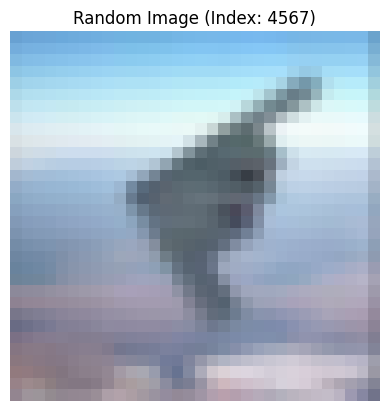

In [19]:
# Snippet per mostrare una immagine random nel dataset

# Prendi un immagini random
random_index = np.random.randint(0, len(train_data))
image_flat = train_data[random_index]  # Shape (3072,)

# Rimodella il vettore piatto (3072,) in immagine RGB (32x32x3)
image_rgb = image_flat.reshape(3, 32, 32).transpose(1, 2, 0) 

# Mostra l'immagine
plt.imshow(image_rgb)   # Matplotlib format --> (height, width, channels)
plt.title(f"Random Image (Index: {random_index})")
plt.axis('off')  # Nascondi gli assi
plt.show()

## 2. Preprocessing

Il dataset di training viene suddiviso in training set e validation set (80% - 20%).  
Successivamente, i pixel vengono normalizzati su una scala da 0 a 1 per facilitare la convergenza dei modelli.

Inoltre, viene implementato un sotto-campionamento per accelerare l'addestramento dei modelli.


In [20]:
# Suddivisione del dataset di training in train and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_data, train_labels, test_size=0.2, 
                                                  random_state=42, shuffle=True)

In [21]:
X_train.shape

(40000, 3072)

In [22]:
X_val.shape

(10000, 3072)

In [23]:
# Applica la Normalizzazione (range [0,1])

X_train = X_train / 255.0
X_val = X_val / 255.0
test_data = test_data / 255.0

In [24]:
X_train.max()

1.0

In [25]:
X_train.min()

0.0

In [26]:
# Sotto-campionamento del training set per ridurre i tempi di allenamento
X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, train_size=0.3, random_state=42, shuffle=True)

In [27]:
print(X_train_sub.shape)
print(y_train_sub.shape)

(12000, 3072)
(12000,)


## 3. Prima valutazione dei modelli

In questa fase sono stati testati quattro modelli di classificazione:
- Regressione Logistica
- Support Vector Machine (SVM)
- k-Nearest Neighbors (k-NN)
- Decision Tree

Per ogni modello vengono calcolati:
- Accuracy sul training e validation set
- F1-score macro (media delle F1 di ogni classe, indipendente dalla distribuzione)

Questa valutazione iniziale serve a identificare il modello con le migliori prestazioni prima di procedere all'ottimizzazione tramite GridSearch.


In [28]:
# Funzione che allena un modello e restituisce accuracy e F1-score su train e validation
def train_evaluation(X_train, y_train, X_val, y_val, model):
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_val)
    
    # Accuracy
    accuracy_train = accuracy_score(y_train, predictions_train)
    accuracy_val = accuracy_score(y_val, predictions_val)

    # F1 score
    fscore_train = f1_score(y_train, predictions_train, average='macro')
    fscore_val = f1_score(y_val, predictions_val, average='macro')

    return accuracy_train, accuracy_val, fscore_train, fscore_val
    

In [29]:
# Modelli da testare
models = {
    'Log_reg': LogisticRegression(random_state=42, max_iter=500), 
    'svm': SVC(random_state=42),
    'knn' : KNeighborsClassifier(), 
    'tree': DecisionTreeClassifier(random_state=42)
}

In [35]:
# Salvo i risultati come dizionari
acc_train_models = {}
acc_val_models = {}
f1_train_models = {}
f1_val_models = {}

# Itero su "models"
for key, value in models.items():
    accuracy_train, accuracy_val, fscore_train, fscore_val = train_evaluation(X_train_sub, y_train_sub, 
                                                                                X_val, y_val, value) 

    acc_train_models[key] = accuracy_train
    acc_val_models[key] = accuracy_val
    f1_train_models[key] = fscore_train
    f1_val_models[key] = fscore_val

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
print(acc_train_models)

{'Log_reg': 0.5785, 'svm': 0.71375, 'knn': 0.47325, 'tree': 1.0}


In [37]:
print(acc_val_models)

{'Log_reg': 0.3536, 'svm': 0.4804, 'knn': 0.2937, 'tree': 0.2402}


In [38]:
print(f1_train_models)

{'Log_reg': 0.5755734456434858, 'svm': 0.7127486265188018, 'knn': 0.46575096232592805, 'tree': 1.0}


In [39]:
print(f1_val_models)

{'Log_reg': 0.35185601983171994, 'svm': 0.4772805288567622, 'knn': 0.274472544909159, 'tree': 0.24037608763620436}


In [31]:
# Funzione per mostrare il classification report
def print_classification_report(X_val, y_val, model):
    predictions_val = model.predict(X_val)
    print(classification_report(y_val, predictions_val))

In [41]:
# Itera su "models"
for key, model in models.items():
    print(f"Model: {key}")
    print_classification_report(X_val, y_val, model)
    print("\n\n")

Model: Log_reg
              precision    recall  f1-score   support

           0       0.38      0.39      0.38       973
           1       0.41      0.41      0.41       979
           2       0.28      0.24      0.26      1030
           3       0.24      0.22      0.23      1023
           4       0.27      0.29      0.28       933
           5       0.28      0.30      0.29      1015
           6       0.37      0.41      0.39       996
           7       0.40      0.39      0.39       994
           8       0.44      0.49      0.47      1017
           9       0.42      0.41      0.41      1040

    accuracy                           0.35     10000
   macro avg       0.35      0.35      0.35     10000
weighted avg       0.35      0.35      0.35     10000




Model: svm
              precision    recall  f1-score   support

           0       0.52      0.52      0.52       973
           1       0.53      0.59      0.56       979
           2       0.38      0.31      0.34      

## 4. Ottimizzazione dell'SVM

Dopo la valutazione iniziale dei modelli, il Support Vector Machine ha mostrato le performance migliori.  
Per questo motivo, è stata effettuata un’ottimizzazione dell’iperparametro `C` tramite `GridSearchCV`, utilizzando `kernel='linear'` per evitare tempi di esecuzione troppo elevati.


In [32]:
# Hyperparameter tuning

param_grid_svm = {
    'C': [0.1, 1, 10],        # low = generalize better (underfitting), high = more rigid (overfitting) 
    'kernel': ['linear']
}

model_svm = SVC(random_state=42)
grid_svm = GridSearchCV(model_svm, param_grid_svm, scoring='accuracy', cv=5, verbose=1)
grid_svm.fit(X_train_sub, y_train_sub)
print("Best configuration: ", grid_svm.best_params_)

print("Best accuracy: ", grid_svm.best_score_)

best_model_svm= grid_svm.best_estimator_
predictions_svm = best_model_svm.predict(X_val)
accuracy_svm = accuracy_score(y_val, predictions_svm)
f1score_svm = f1_score(y_val, predictions_svm, average='macro')
print("Accuracy:", accuracy_svm)
print("F1 score:", f1score_svm)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best configuration:  {'C': 0.1, 'kernel': 'linear'}
Best accuracy:  0.3671666666666666
Accuracy: 0.3753
F1 score: 0.37544056584881247


### Confronto con la valutazione iniziale

Nella fase iniziale, utilizzando la funzione `train_evaluation`, il modello SVM ha ottenuto:
- Accuracy su training: **71.4%**
- F1-score su training: **71.3%**
- Accuracy su validation: **48.0%**
- F1-score su validation: **47.7%**

Dopo l'ottimizzazione tramite `GridSearchCV`, con `kernel='linear'` e `cv=5`, il miglior modello ha ottenuto:
- Accuracy su validation: **37.5%**
- F1-score su validation: **37.5%**

**Perché le performance sembrano peggiorate?**

- Durante la GridSearchCV, i dati di training vengono suddivisi in 5 fold → ogni modello viene addestrato su una porzione più piccola del dataset → meno dati = modelli meno potenti.
- Il modello trovato da GridSearchCV è ottimizzato per **generalizzare** su dati mai visti, non per massimizzare la performance su una divisione fissa.



In [33]:
best_model_svm

SVC(C=0.1, kernel='linear', random_state=42)

## 5. Allenamento del modello finale e valutazione sul test set

Una volta selezionati gli iperparametri ottimali (`C=0.1`, `kernel='linear'`),  
il modello SVM viene addestrato nuovamente utilizzando **l'intero dataset di training disponibile**, composto dai dati di training e validation (totale: 100% dei dati originali di training).

Questo approccio permette di sfruttare al massimo i dati per ottenere una performance più stabile.  
Il modello finale è stato infine valutato sul **test set**, completamente separato e mai visto prima dal modello.

Di seguito sono riportati i risultati ottenuti.


In [30]:
# Unisco train e validation
X_final_train = np.vstack((X_train, X_val))
y_final_train = np.concatenate((y_train, y_val))

# Ricreo il modello con i migliori hypeparametri
final_model = SVC(kernel='linear', C=0.1, random_state=42)
final_model.fit(X_final_train, y_final_train)

# Test finale
predictions_test = final_model.predict(test_data)
accuracy_test = accuracy_score(test_labels, predictions_test)
f1score_test = f1_score(test_labels, predictions_test, average='macro')

print("Test Accuracy:", accuracy_test)
print("Test F1 Score:", f1score_test)


Test Accuracy: 0.4104
Test F1 Score: 0.4092877300226328


In [33]:
# Classi di CIFAR-10
class_labels = {
    0: 'airplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}

# Visualizza le etichette in ordine
for label, name in class_labels.items():
    print(f"Classe {label}: {name}")


Classe 0: airplane
Classe 1: automobile
Classe 2: bird
Classe 3: cat
Classe 4: deer
Classe 5: dog
Classe 6: frog
Classe 7: horse
Classe 8: ship
Classe 9: truck


In [32]:
# Stampa un report completo delle metriche di classificazione per ogni classe
print(classification_report(test_labels, predictions_test))

              precision    recall  f1-score   support

           0       0.44      0.51      0.47      1000
           1       0.46      0.48      0.47      1000
           2       0.31      0.32      0.32      1000
           3       0.27      0.28      0.28      1000
           4       0.36      0.30      0.33      1000
           5       0.32      0.32      0.32      1000
           6       0.44      0.48      0.46      1000
           7       0.49      0.43      0.46      1000
           8       0.53      0.54      0.54      1000
           9       0.47      0.45      0.46      1000

    accuracy                           0.41     10000
   macro avg       0.41      0.41      0.41     10000
weighted avg       0.41      0.41      0.41     10000



In [36]:
# Trova gli indici degli errori
misclassified_indices = np.where(predictions_test != test_labels)[0]
len(misclassified_indices)

5896

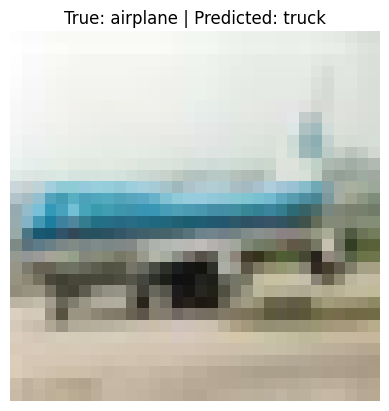

In [38]:
# Visualizza un'immagine del test set classificata in modo errato dal modello

# Seleziona un errore casuale
random_idx = np.random.choice(misclassified_indices)
image_flat = test_data[random_idx]
image_rgb = image_flat.reshape(3, 32, 32).transpose(1, 2, 0)

# Ottieni etichetta reale e predetta
true_label = test_labels[random_idx]
pred_label = predictions_test[random_idx]

# Visualizza l'immagine sbagliata
plt.imshow(image_rgb)
plt.title(f"True: {class_labels[true_label]} | Predicted: {class_labels[pred_label]}")
plt.axis('off')
plt.show()

### Considerazioni finali

Il modello SVM finale ha ottenuto sul test set:
- Accuracy: **41.0%**
- F1-score macro: **40.9%**

Questi valori sono coerenti con quelli ottenuti durante la validazione. 

Dal `classification_report`, possiamo osservare che:
- Il modello riesce a distinguere meglio alcune classi come **ship (classe 8)** con un F1-score di 0.54.
- Le classi più difficili da distinguere risultano essere:
  - **bird (classe 2)**
  - **cat (classe 3)**
  - **deer (classe 4)**
  - **dog (classe 5)**

Nel complesso, il modello mantiene una buona **coerenza tra precision, recall e F1-score** su quasi tutte le classi,  

Modelli più complessi (come reti neurali convoluzionali) potrebbero migliorare ulteriormente le performance, ma con un costo computazionale molto più alto.
